# ML Overheating Predictor — Interactive Testing

**Purpose:** Manually test and explore the trained overheating prediction models.

**Two modes:**
1. **Data Replay** — pick a date from the test set, see what the model predicted vs. what actually happened.
2. **Manual Input** — adjust feature sliders and press *Predict* to explore the model's behaviour.

**Requires:** notebook `03_overheating_ml_training.ipynb` has been run first so that model files exist in `models/`.

**Dependencies:** `ipywidgets` — install with `pip install ipywidgets` if missing.

## 0. Setup & Imports

In [1]:
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("ipywidgets not found. Install with: pip install ipywidgets")
    print("Interactive panels will be disabled; static examples will be shown instead.")

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
DATA_DIR     = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../../.data"))
MODELS_DIR   = os.path.join(NOTEBOOK_DIR, "models")

SENSOR_CSV   = os.path.join(DATA_DIR, "sensordaten_2025-06-19_ab.csv")
PV_CSV       = os.path.join(DATA_DIR, "PV-Daten_2025-06-19_ab.csv")
META_PATH    = os.path.join(MODELS_DIR, "model_metadata.json")
RF_PATH      = os.path.join(MODELS_DIR, "overheating_predictor_rf.joblib")
LGBM_PATH    = os.path.join(MODELS_DIR, "overheating_predictor_lgbm.joblib")

# ── Check model files exist ───────────────────────────────────────────────────
missing = [p for p in [META_PATH, RF_PATH, LGBM_PATH] if not os.path.exists(p)]
if missing:
    print("⚠️  Missing model files — run notebook 03 first:")
    for m in missing:
        print(f"   {m}")
else:
    print("✓ All model files found")

✓ All model files found


In [2]:
# ── Load metadata & models ────────────────────────────────────────────────────
with open(META_PATH) as fh:
    meta = json.load(fh)

FEATURE_COLS         = meta["feature_cols"]
OVERHEAT_THRESHOLD_C = meta["overheat_threshold_c"]
LABEL_HORIZON_H      = meta["label_horizon_h"]
STEPS_PER_HOUR       = 12
LABEL_HORIZON_STEPS  = LABEL_HORIZON_H * STEPS_PER_HOUR
RF_THRESHOLD         = meta["rf"]["threshold"]
LGBM_THRESHOLD       = meta["lgbm"]["threshold"]
BOOST_NAME           = meta["lgbm"]["model_type"]
BEST_MODEL           = meta["best_model"]

rf_model   = joblib.load(RF_PATH)
lgbm_model = joblib.load(LGBM_PATH)

print(f"Models loaded.")
print(f"  Threshold  : {OVERHEAT_THRESHOLD_C} °C")
print(f"  Horizon    : {LABEL_HORIZON_H} h")
print(f"  Best model : {BEST_MODEL}")
print(f"  RF  AUC    : {meta['rf']['roc_auc']}   threshold={RF_THRESHOLD}")
print(f"  {BOOST_NAME:10s} AUC: {meta['lgbm']['roc_auc']}   threshold={LGBM_THRESHOLD}")

Models loaded.
  Threshold  : 23.1 °C
  Horizon    : 8 h
  Best model : lgbm
  RF  AUC    : 0.82734   threshold=0.41363
  LightGBM   AUC: 0.83613   threshold=0.00411


## 1. Load & Prepare Dataset

In [3]:
# ── Reload + merge data (same pipeline as notebook 03) ───────────────────────
PTH_H_MAX_W = 1000.0

print("Loading sensor data…")
sensor_raw = pd.concat(
    [c for c in pd.read_csv(SENSOR_CSV, chunksize=50_000, low_memory=False)],
    ignore_index=True,
)
print("Loading PV data…")
pv_raw = pd.concat(
    [c for c in pd.read_csv(PV_CSV, chunksize=50_000, low_memory=False)],
    ignore_index=True,
)

sensor_raw["time"] = pd.to_datetime(sensor_raw["time"], utc=True, errors="coerce")
pv_raw["time"]     = pd.to_datetime(pv_raw["time"],     utc=True, errors="coerce")
sensor_raw = sensor_raw.dropna(subset=["time"]).set_index("time").sort_index()
pv_raw     = pv_raw.dropna(subset=["time"]).set_index("time").sort_index()

sensor_5m = sensor_raw.resample("5min").mean(numeric_only=True)
pv_5m     = pv_raw[["PV_Generate"]].resample("5min").mean(numeric_only=True)
df        = sensor_5m.join(pv_5m, how="left")

# ── Forward-fill sparse columns (mirrors notebook 03 pipeline) ────────────────
# AT_roh_Nh: HA weather API writes once per hour; ffill carries it forward up to 2 h.
at_forecast_cols = [c for c in df.columns if c.startswith("AT_roh_")]
if at_forecast_cols:
    df[at_forecast_cols] = df[at_forecast_cols].ffill(limit=24)
# VLT / RLT / Vol / Pth_PC: only logged while HP is running.
for col in ["VLT", "RLT", "Vol", "Pth_PC", "Pel"]:
    if col in df.columns:
        df[col] = df[col].ffill(limit=6).fillna(0.0)

indoor_cols = [c for c in ["RT_Flur_OG","RT_Bad_OG","RT_WZ","RT_Flur_EG"] if c in df.columns]
df["indoor_temp"] = df[indoor_cols].median(axis=1)
df["PV_Generate"] = df["PV_Generate"].clip(lower=0)

# Day filter
df["date"] = df.index.date
day_stats  = df.groupby("date").agg(
    pv_null_rows=("PV_Generate", lambda x: x.isna().sum()),
    pth_h_max=("Pth_H", "max"),
)
valid_dates = set(day_stats[(day_stats["pv_null_rows"]==0) & (day_stats["pth_h_max"]<PTH_H_MAX_W)].index)
df_valid = df[df["date"].isin(valid_dates)].copy()

# Feature engineering
df_valid["indoor_margin"]   = df_valid["indoor_temp"] - OVERHEAT_THRESHOLD_C
df_valid["indoor_trend_30m"]= df_valid["indoor_temp"] - df_valid["indoor_temp"].shift(6)
df_valid["indoor_trend_1h"] = df_valid["indoor_temp"] - df_valid["indoor_temp"].shift(12)
df_valid["at_delta_indoor"] = df_valid["AT"] - df_valid["indoor_temp"]
df_valid["pv_roll_1h"]      = df_valid["PV_Generate"].rolling(12, min_periods=6).mean()
df_valid["pv_roll_2h"]      = df_valid["PV_Generate"].rolling(24, min_periods=12).mean()
hour_frac = df_valid.index.hour + df_valid.index.minute / 60.0
df_valid["hour_sin"] = np.sin(2*np.pi*hour_frac/24)
df_valid["hour_cos"] = np.cos(2*np.pi*hour_frac/24)
doy = df_valid.index.dayofyear
df_valid["doy_sin"] = np.sin(2*np.pi*doy/365)
df_valid["doy_cos"] = np.cos(2*np.pi*doy/365)

# ── HP thermal state features (mirrors notebook 03 pipeline) ─────────────────
if "Pth_PC" in df_valid.columns:
    df_valid["thermal_power_kw"] = df_valid["Pth_PC"] / 1000.0
else:
    df_valid["thermal_power_kw"] = 0.0
if "VLT" in df_valid.columns and "RLT" in df_valid.columns:
    df_valid["delta_t"]            = df_valid["VLT"] - df_valid["RLT"]
    df_valid["outlet_indoor_diff"] = df_valid["VLT"] - df_valid["indoor_temp"]
else:
    df_valid["delta_t"]            = 0.0
    df_valid["outlet_indoor_diff"] = 0.0

# Pre-compute model predictions over the entire valid dataset
model_df = df_valid[FEATURE_COLS].dropna()
assert len(model_df) >= 100, (
    f"Only {len(model_df)} rows with all features — "
    "check ffill / feature engineering above matches notebook 03.")
X_all    = model_df.values
rf_prob_all   = rf_model.predict_proba(X_all)[:, 1]
lgbm_prob_all = lgbm_model.predict_proba(X_all)[:, 1]

VALID_DATES_SORTED = sorted(valid_dates)
if not VALID_DATES_SORTED:
    raise RuntimeError(
        "No valid days in model_df. Run notebook 03 first and "
        "confirm the model was trained on your dataset.")
print(f"\nValid days available: {len(VALID_DATES_SORTED)}")
print(f"  from {VALID_DATES_SORTED[0]} to {VALID_DATES_SORTED[-1]}")


Loading sensor data…
Loading PV data…

Valid days available: 52
  from 2025-07-08 to 2025-09-20


## 2. Data Replay — pick a date and see predictions vs. reality

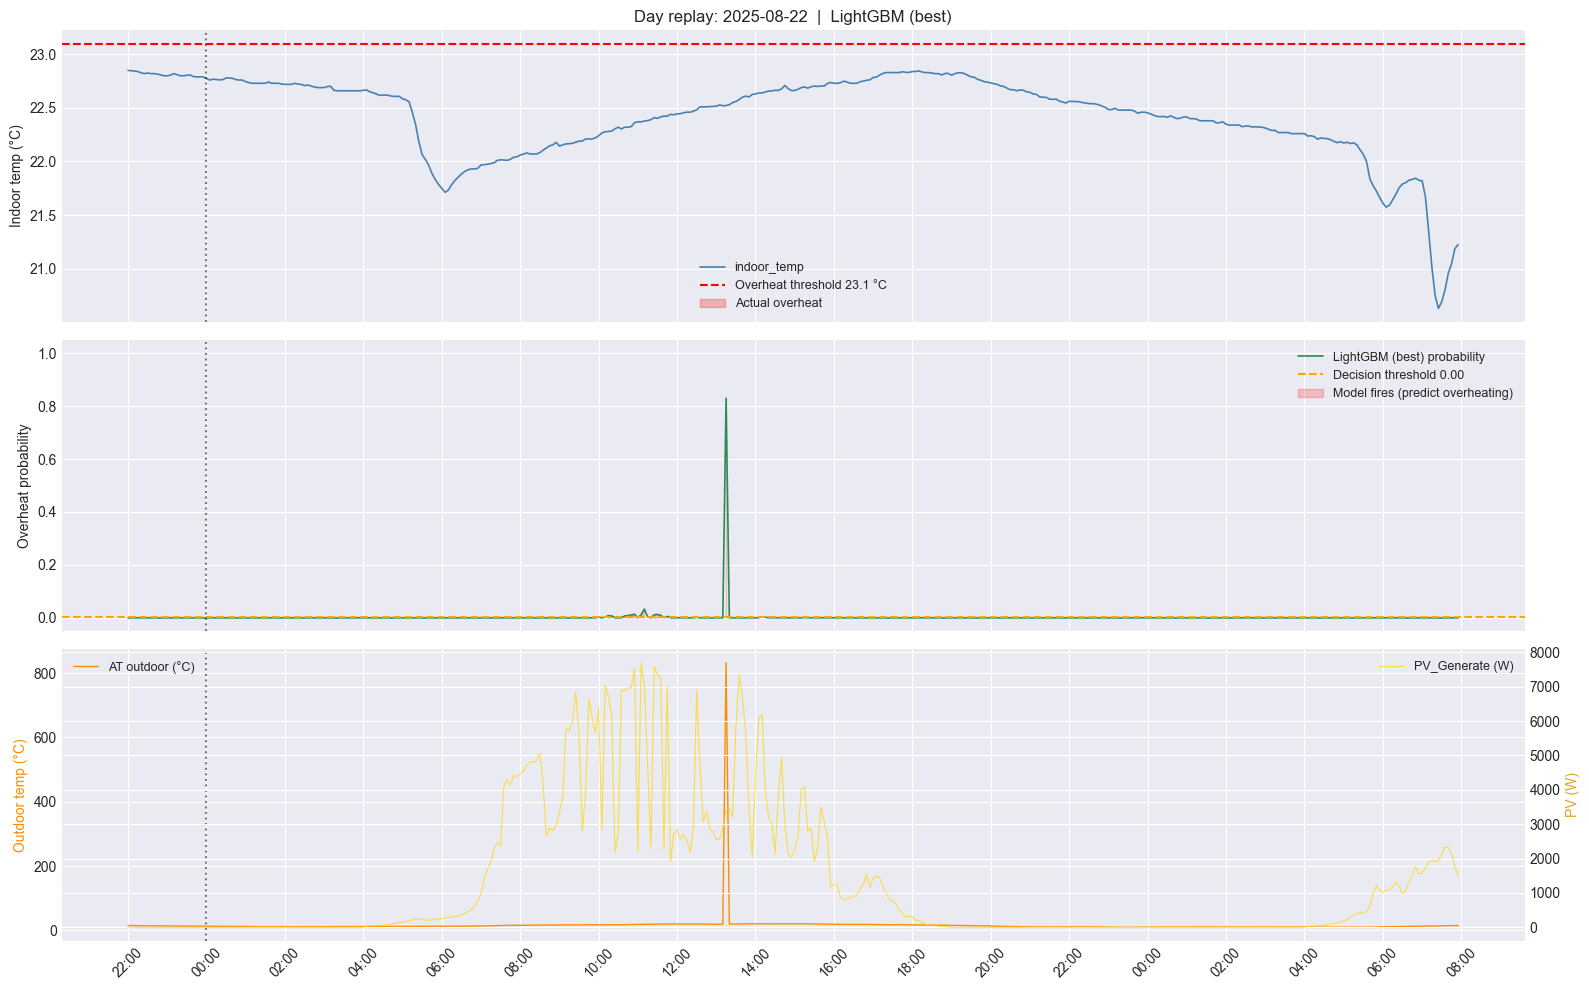


Example plotted for: 2025-08-22


In [4]:
def plot_day_replay(selected_date_str: str, model_choice: str = "best"):
    """Plot one full day: indoor temp trajectory + model probability."""
    import datetime as dt
    try:
        sel_date = dt.date.fromisoformat(selected_date_str)
    except ValueError:
        print("Invalid date format. Use YYYY-MM-DD")
        return

    # Rows for this day and look-ahead window (needed to show actual future)
    day_mask  = model_df.index.date == sel_date
    if not day_mask.any():
        print(f"No data for {sel_date} in the valid-day dataset.")
        return

    day_idx   = np.where(day_mask)[0]
    idx_start = max(0, day_idx[0] - 24)   # 2h context before
    idx_end   = min(len(model_df), day_idx[-1] + LABEL_HORIZON_STEPS + 1)

    time_slice  = model_df.index[idx_start:idx_end]
    indoor_sl   = df_valid.loc[time_slice, "indoor_temp"]
    at_sl       = df_valid.loc[time_slice, "AT"]
    pv_sl       = df_valid.loc[time_slice, "PV_Generate"]

    rf_sl   = rf_prob_all[idx_start:idx_end]
    lgbm_sl = lgbm_prob_all[idx_start:idx_end]

    if model_choice == "best":
        use_prob  = rf_sl   if BEST_MODEL == "rf" else lgbm_sl
        use_thr   = RF_THRESHOLD if BEST_MODEL == "rf" else LGBM_THRESHOLD
        use_name  = "RF (best)" if BEST_MODEL == "rf" else f"{BOOST_NAME} (best)"
    elif model_choice == "rf":
        use_prob, use_thr, use_name = rf_sl, RF_THRESHOLD, "RandomForest"
    else:
        use_prob, use_thr, use_name = lgbm_sl, LGBM_THRESHOLD, BOOST_NAME

    # Shaded regions where model fires
    fires = use_prob >= use_thr

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    # Panel 1: indoor temperature
    axes[0].plot(time_slice, indoor_sl.values, color="steelblue", linewidth=1.2, label="indoor_temp")
    axes[0].axhline(OVERHEAT_THRESHOLD_C, color="red", linestyle="--",
                    label=f"Overheat threshold {OVERHEAT_THRESHOLD_C} °C")
    axes[0].fill_between(time_slice, OVERHEAT_THRESHOLD_C, indoor_sl.values,
                         where=indoor_sl.values > OVERHEAT_THRESHOLD_C,
                         alpha=0.25, color="red", label="Actual overheat")
    # Mark start of selected day
    day_start_time = model_df.index[day_idx[0]]
    axes[0].axvline(day_start_time, color="black", linestyle=":", alpha=0.5)
    axes[0].set_ylabel("Indoor temp (°C)")
    axes[0].legend(fontsize=9)
    axes[0].set_title(f"Day replay: {sel_date}  |  {use_name}")

    # Panel 2: model probability
    axes[1].plot(time_slice, use_prob, color="seagreen", linewidth=1.2,
                 label=f"{use_name} probability")
    axes[1].axhline(use_thr, color="orange", linestyle="--",
                    label=f"Decision threshold {use_thr:.2f}")
    axes[1].fill_between(time_slice, 0, use_prob, where=fires,
                         alpha=0.2, color="red", label="Model fires (predict overheating)")
    axes[1].axvline(day_start_time, color="black", linestyle=":", alpha=0.5)
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_ylabel("Overheat probability")
    axes[1].legend(fontsize=9)

    # Panel 3: context (AT + PV)
    ax3 = axes[2]
    ax3b = ax3.twinx()
    ax3.plot(time_slice, at_sl.values, color="darkorange", linewidth=1.0, label="AT outdoor (°C)")
    ax3b.plot(time_slice, pv_sl.values, color="gold", linewidth=0.8, alpha=0.7, label="PV_Generate (W)")
    ax3.set_ylabel("Outdoor temp (°C)", color="darkorange")
    ax3b.set_ylabel("PV (W)", color="goldenrod")
    ax3.legend(loc="upper left", fontsize=9)
    ax3b.legend(loc="upper right", fontsize=9)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax3.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
    ax3.axvline(day_start_time, color="black", linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


# ── Static example (always runs) ─────────────────────────────────────────────
# Use the first valid day in the test portion (last 25% of valid days)
test_start_day = VALID_DATES_SORTED[int(len(VALID_DATES_SORTED) * 0.75)]
plot_day_replay(str(test_start_day))
print(f"\nExample plotted for: {test_start_day}")

In [5]:
# ── Interactive date picker (requires ipywidgets) ────────────────────────────
if HAS_WIDGETS:
    date_options = [str(d) for d in VALID_DATES_SORTED]

    date_dd = widgets.Dropdown(
        options=date_options,
        value=str(test_start_day),
        description="Date:",
        layout=widgets.Layout(width="220px"),
    )
    model_dd = widgets.Dropdown(
        options=[("Best model", "best"), ("RandomForest", "rf"), (f"{BOOST_NAME}", "lgbm")],
        description="Model:",
        layout=widgets.Layout(width="220px"),
    )
    replay_btn   = widgets.Button(description="Plot day", button_style="primary")
    replay_out   = widgets.Output()

    def on_replay_click(_):
        with replay_out:
            clear_output(wait=True)
            plot_day_replay(date_dd.value, model_dd.value)

    replay_btn.on_click(on_replay_click)
    display(widgets.HBox([date_dd, model_dd, replay_btn]), replay_out)
else:
    print("ipywidgets not available — change `test_start_day` manually and re-run the cell above.")

Output()

## 3. Manual Feature Input — explore 'what if?'

In [6]:
def predict_manual(feature_values: dict) -> dict:
    """Run both models for a manually constructed feature vector.

    Missing features default to the column mean from the training set.
    Returns probabilities and decisions for both models.
    """
    row = {c: feature_values.get(c, model_df[c].mean()) for c in FEATURE_COLS}
    X   = np.array([[row[c] for c in FEATURE_COLS]])

    rf_p   = rf_model.predict_proba(X)[0, 1]
    lgbm_p = lgbm_model.predict_proba(X)[0, 1]

    return {
        "rf_probability"     : round(float(rf_p),   4),
        "lgbm_probability"   : round(float(lgbm_p), 4),
        "rf_decision"        : bool(rf_p   >= RF_THRESHOLD),
        "lgbm_decision"      : bool(lgbm_p >= LGBM_THRESHOLD),
        "best_probability"   : round(float(rf_p if BEST_MODEL=='rf' else lgbm_p), 4),
        "best_decision"      : bool((rf_p if BEST_MODEL=='rf' else lgbm_p) >=
                                    (RF_THRESHOLD if BEST_MODEL=='rf' else LGBM_THRESHOLD)),
    }


# ── Quick sanity test ────────────────────────────────────────────────────────
test_cold = predict_manual({"indoor_temp": 20.0, "AT": 10.0, "PV_Generate": 0.0})
test_hot  = predict_manual({"indoor_temp": 22.5, "AT": 30.0, "PV_Generate": 5000.0,
                             "indoor_trend_30m": 0.4, "indoor_margin": -0.6})

print("Cold winter day  → predict_manual:", test_cold)
print("Hot summer day   → predict_manual:", test_hot)

Cold winter day  → predict_manual: {'rf_probability': 0.219, 'lgbm_probability': 0.0, 'rf_decision': False, 'lgbm_decision': False, 'best_probability': 0.0, 'best_decision': False}
Hot summer day   → predict_manual: {'rf_probability': 0.3998, 'lgbm_probability': 0.0068, 'rf_decision': False, 'lgbm_decision': True, 'best_probability': 0.0068, 'best_decision': True}


In [7]:
# ── Interactive sliders ──────────────────────────────────────────────────────
if HAS_WIDGETS:
    # Compute dataset statistics for slider defaults / ranges
    col_stats = model_df.agg(["min", "max", "mean"]).T

    def make_slider(col, desc, step=0.1):
        mn  = round(float(col_stats.loc[col, "min"]),  2) if col in col_stats.index else -50.0
        mx  = round(float(col_stats.loc[col, "max"]),  2) if col in col_stats.index else 50.0
        val = round(float(col_stats.loc[col, "mean"]), 2) if col in col_stats.index else 0.0
        return widgets.FloatSlider(
            value=val, min=mn, max=mx, step=step,
            description=desc,
            style={"description_width": "180px"},
            layout=widgets.Layout(width="500px"),
            continuous_update=False,
        )

    # Key sliders — adjust step sizes to suit variable ranges
    sl_indoor     = make_slider("indoor_temp",      "Indoor temp (°C)",      0.1)
    sl_margin     = make_slider("indoor_margin",    "Margin to 23.1°C (K)",  0.1)
    sl_trend30    = make_slider("indoor_trend_30m", "Indoor trend 30m (K)",  0.05)
    sl_at         = make_slider("AT",               "Outdoor AT (°C)",        0.5)
    sl_at_1h      = make_slider("AT_roh_1h",        "AT forecast +1h (°C)",  0.5) if "AT_roh_1h" in FEATURE_COLS else None
    sl_at_4h      = make_slider("AT_roh_4h",        "AT forecast +4h (°C)",  0.5) if "AT_roh_4h" in FEATURE_COLS else None
    sl_at_8h      = make_slider("AT_roh_8h",        "AT forecast +8h (°C)",  0.5) if "AT_roh_8h" in FEATURE_COLS else None
    sl_pv         = make_slider("PV_Generate",      "PV generation (W)",    100.0)
    sl_pv1h       = make_slider("pv_roll_1h",       "PV rolling 1h (W)",    100.0)
    sl_thermal_pw  = make_slider("thermal_power_kw",   "Thermal power (kW)",    0.05) if "thermal_power_kw"   in FEATURE_COLS else None
    sl_delta_t     = make_slider("delta_t",             "Supply-Return ΔT (K)",  0.1)  if "delta_t"            in FEATURE_COLS else None
    sl_outlet_diff = make_slider("outlet_indoor_diff",  "Outlet-Indoor diff (K)",0.1)  if "outlet_indoor_diff"  in FEATURE_COLS else None
    sl_hour       = widgets.IntSlider(value=12, min=0, max=23, step=1,
                                       description="Hour of day",
                                       style={"description_width": "180px"},
                                       layout=widgets.Layout(width="500px"),
                                       continuous_update=False)

    predict_btn = widgets.Button(description="Predict", button_style="success",
                                  layout=widgets.Layout(width="140px"))
    out_manual  = widgets.Output()

    all_sliders = [s for s in [sl_indoor, sl_margin, sl_trend30, sl_at,
                                sl_at_1h, sl_at_4h, sl_at_8h,
                                sl_pv, sl_pv1h, sl_thermal_pw, sl_delta_t, sl_outlet_diff, sl_hour] if s is not None]

    def on_predict_click(_):
        hour_val    = sl_hour.value
        hour_frac_  = hour_val
        doy_val     = 180  # mid-year default

        feats = {
            "indoor_temp"      : sl_indoor.value,
            "indoor_margin"    : sl_margin.value,
            "indoor_trend_30m" : sl_trend30.value,
            "indoor_trend_1h"  : sl_trend30.value * 2,  # approximate
            "AT"               : sl_at.value,
            "at_delta_indoor"  : sl_at.value - sl_indoor.value,
            "PV_Generate"      : sl_pv.value,
            "pv_roll_1h"       : sl_pv1h.value,
            "pv_roll_2h"       : sl_pv1h.value,
            "hour_sin"         : np.sin(2 * np.pi * hour_frac_ / 24),
            "hour_cos"         : np.cos(2 * np.pi * hour_frac_ / 24),
            "doy_sin"          : np.sin(2 * np.pi * doy_val / 365),
            "doy_cos"          : np.cos(2 * np.pi * doy_val / 365),
        }
        if sl_at_1h:  feats["AT_roh_1h"] = sl_at_1h.value
        if sl_at_4h:  feats["AT_roh_4h"] = sl_at_4h.value
        if sl_at_8h:  feats["AT_roh_8h"] = sl_at_8h.value
        if sl_thermal_pw:  feats["thermal_power_kw"]   = sl_thermal_pw.value
        if sl_delta_t:     feats["delta_t"]             = sl_delta_t.value
        if sl_outlet_diff: feats["outlet_indoor_diff"]  = sl_outlet_diff.value

        result = predict_manual(feats)

        with out_manual:
            clear_output(wait=True)
            # Gauge-style summary
            fig, ax = plt.subplots(figsize=(10, 3))
            models_shown = [
                ("RandomForest",  result["rf_probability"],   RF_THRESHOLD),
                (BOOST_NAME,      result["lgbm_probability"], LGBM_THRESHOLD),
            ]
            colors = ["tomato" if p >= t else "steelblue" for _, p, t in models_shown]
            bars   = ax.barh(
                [m for m, _, _ in models_shown],
                [p for _, p, _ in models_shown],
                color=colors, edgecolor="white", height=0.4,
            )
            for bar, (name, prob, thr) in zip(bars, models_shown):
                ax.text(min(prob + 0.01, 0.98), bar.get_y() + bar.get_height()/2,
                        f"{prob:.3f}  {'⚠ OVERHEATING' if prob>=thr else '✓ OK'}",
                        va="center", fontsize=12,
                        color="red" if prob >= thr else "darkgreen")
                ax.axvline(thr, color="black", linestyle="--", alpha=0.5, linewidth=1.2)
            ax.set_xlim(0, 1.1)
            ax.set_xlabel("Predicted probability of overheating within 8h")
            ax.set_title(f"indoor={sl_indoor.value}°C  AT={sl_at.value}°C  PV={sl_pv.value}W  hour={hour_val}:00")
            plt.tight_layout()
            plt.show()

    predict_btn.on_click(on_predict_click)

    box_left  = widgets.VBox(all_sliders[:len(all_sliders)//2])
    box_right = widgets.VBox(all_sliders[len(all_sliders)//2:])
    display(
        widgets.HTML("<h4>Manual feature input — adjust sliders, then press Predict</h4>"),
        widgets.HBox([box_left, box_right]),
        predict_btn,
        out_manual,
    )
else:
    print("ipywidgets not available. Use predict_manual() directly:")
    print("  result = predict_manual({'indoor_temp': 22.5, 'AT': 30.0, 'PV_Generate': 4000.0})")
    print("  print(result)")

HTML(value='<h4>Manual feature input — adjust sliders, then press Predict</h4>')

Button(button_style='success', description='Predict', layout=Layout(width='140px'), style=ButtonStyle())

Output()

## 4. Sensitivity Analysis — vary one feature, hold others at mean

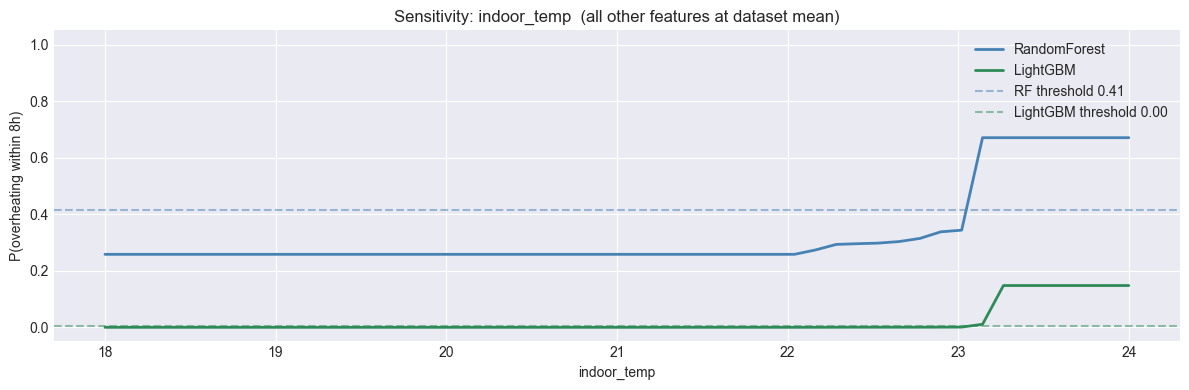

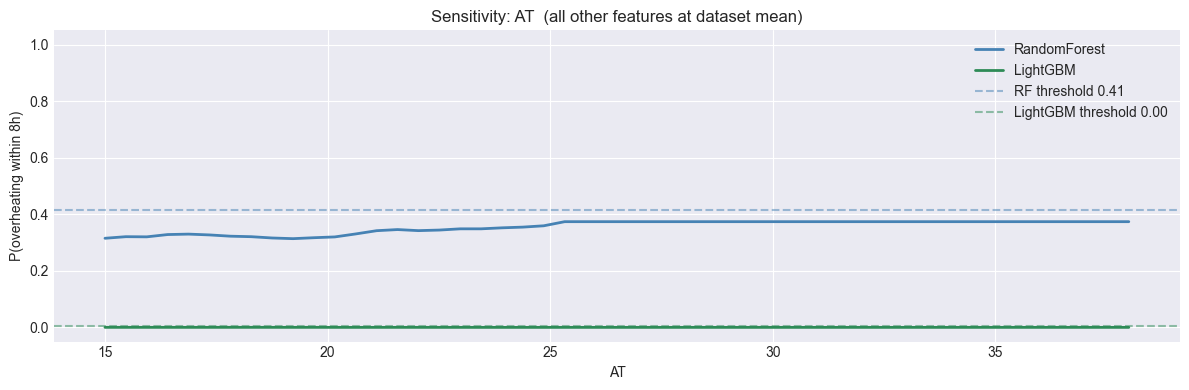

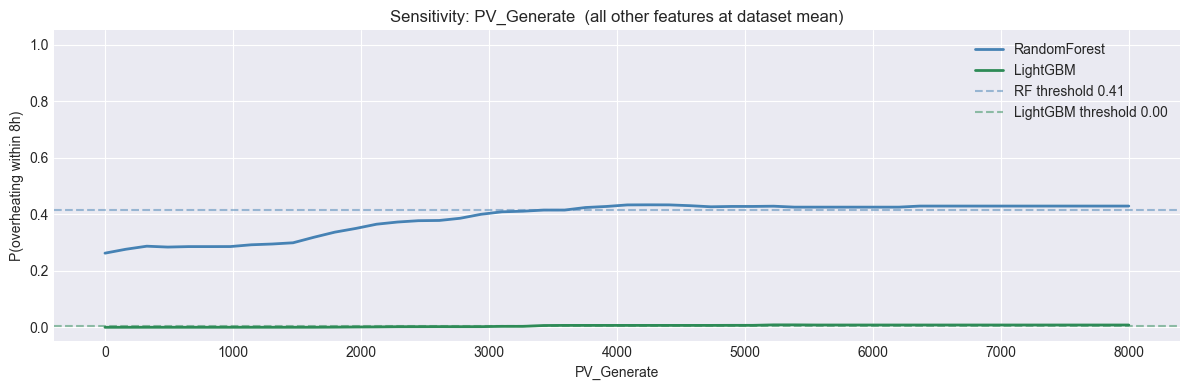

In [8]:
def sensitivity_plot(feature: str, sweep_range=None, n_points=50, fixed_overrides=None):
    """Plot probability as one feature varies while all others stay at their mean."""
    baseline = {c: float(model_df[c].mean()) for c in FEATURE_COLS}
    if fixed_overrides:
        baseline.update(fixed_overrides)

    if sweep_range is None:
        col_min = float(model_df[feature].quantile(0.01))
        col_max = float(model_df[feature].quantile(0.99))
        sweep_range = (col_min, col_max)

    sweep = np.linspace(sweep_range[0], sweep_range[1], n_points)
    rf_probs, lgbm_probs = [], []

    for val in sweep:
        row = baseline.copy()
        row[feature] = val
        X = np.array([[row[c] for c in FEATURE_COLS]])
        rf_probs.append(rf_model.predict_proba(X)[0, 1])
        lgbm_probs.append(lgbm_model.predict_proba(X)[0, 1])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sweep, rf_probs,   color="steelblue", linewidth=2, label="RandomForest")
    ax.plot(sweep, lgbm_probs, color="seagreen",  linewidth=2, label=BOOST_NAME)
    ax.axhline(RF_THRESHOLD,   color="steelblue", linestyle="--", alpha=0.5, label=f"RF threshold {RF_THRESHOLD:.2f}")
    ax.axhline(LGBM_THRESHOLD, color="seagreen",  linestyle="--", alpha=0.5, label=f"{BOOST_NAME} threshold {LGBM_THRESHOLD:.2f}")
    ax.set_xlabel(feature)
    ax.set_ylabel("P(overheating within 8h)")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"Sensitivity: {feature}  (all other features at dataset mean)")
    ax.legend()
    plt.tight_layout()
    plt.show()


# ── Example sensitivity plots ─────────────────────────────────────────────────
sensitivity_plot("indoor_temp",  sweep_range=(18.0, 24.0))
sensitivity_plot("AT",           sweep_range=(15.0, 38.0))
sensitivity_plot("PV_Generate",  sweep_range=(0,    8000))

In [ ]:
# ── Interactive sensitivity selector ─────────────────────────────────────────
if HAS_WIDGETS:
    feat_dd = widgets.Dropdown(
        options=FEATURE_COLS,
        description="Feature:",
        layout=widgets.Layout(width="300px"),
    )
    sens_btn = widgets.Button(description="Plot sensitivity", button_style="info")
    sens_out = widgets.Output()

    def on_sens_click(_):
        with sens_out:
            clear_output(wait=True)
            sensitivity_plot(feat_dd.value)

    sens_btn.on_click(on_sens_click)
    display(widgets.HBox([feat_dd, sens_btn]), sens_out)

Output()

## 5. Missed / False Alarm Analysis

In [11]:
# ── Identify false negatives (missed overheating) on the test portion ─────────
TRAIN_FRACTION   = 0.75
split_idx        = int(len(model_df) * TRAIN_FRACTION)
STEPS_PER_HOUR   = 12

def make_label(series, horizon_steps, threshold):
    return (
        series[::-1].rolling(horizon_steps, min_periods=horizon_steps).max()[::-1] > threshold
    ).astype("Int8")

# Compute labels on the FULL df_valid series so the reverse-rolling window
# has full day context at every point, then align to model_df's index.
labels_full  = make_label(df_valid["indoor_temp"], LABEL_HORIZON_STEPS, OVERHEAT_THRESHOLD_C)
labels_8h    = labels_full.reindex(model_df.index)

test_labels    = labels_8h.iloc[split_idx:].values.astype(float)
test_rf_pred   = (rf_prob_all[split_idx:]   >= RF_THRESHOLD).astype(int)
test_lgbm_pred = (lgbm_prob_all[split_idx:] >= LGBM_THRESHOLD).astype(int)

# Best model
best_prob_test = rf_prob_all[split_idx:]   if BEST_MODEL == "rf" else lgbm_prob_all[split_idx:]
best_thr       = RF_THRESHOLD if BEST_MODEL == "rf" else LGBM_THRESHOLD
best_pred_test = (best_prob_test >= best_thr).astype(int)

valid_mask     = ~np.isnan(test_labels)
test_labels    = test_labels[valid_mask].astype(int)
best_pred_test = best_pred_test[valid_mask]

fn_mask = (test_labels == 1) & (best_pred_test == 0)  # missed overheating
fp_mask = (test_labels == 0) & (best_pred_test == 1)  # false alarm

print(f"Test rows (best model)  : {valid_mask.sum():,}")
print(f"  False negatives (miss): {fn_mask.sum():,}  ({fn_mask.sum()/max(test_labels.sum(),1)*100:.1f}% of actual overheat events)")
print(f"  False positives (FA)  : {fp_mask.sum():,}  ({fp_mask.sum()/max((test_labels==0).sum(),1)*100:.1f}% of no-overheat rows)")


Test rows (best model)  : 3,716
  False negatives (miss): 413  (19.9% of actual overheat events)
  False positives (FA)  : 256  (15.6% of no-overheat rows)
